In [16]:
import sys, os
sys.path.append('../data_extraction')

import matplotlib.pyplot as plt
import numpy as np

import cv2
from skimage.draw import disk

from sklearn.model_selection import train_test_split

from LRO_data_class import getFilteredLabels, LunarDataset

In [2]:
ds = LunarDataset()

dataDEM = ds.DEMLunarData
dataWAC = ds.regionalLunarData

filteredLabels = getFilteredLabels()

In [3]:
filteredLabels.head()

,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
0,01-1-189527,59.99990,162.496,59.99990,162.496,1.76788,0.020729,1.79156,1.73944,0.239466,...,78.2722,0.000297,0.000611,0.020463,0.022637,20.55530,0.068162,0.017834,0.810232,11
1,01-1-189539,59.99710,123.437,60.00110,123.452,3.33136,0.098881,3.52154,2.56769,0.684365,...,118.2220,0.000456,0.001212,0.031186,0.051761,1.44716,0.017104,0.030197,0.680784,14
2,02-1-009148,1.22341,179.994,1.22345,179.994,4.33920,0.058872,4.46190,4.22970,0.318390,...,132.3200,0.000213,0.000213,0.016504,0.014545,3.23978,0.014254,0.005328,0.923478,42
3,02-1-033235,9.64757,179.997,9.66750,179.996,3.89968,0.179441,5.45599,3.62284,0.747722,...,92.0073,0.003449,0.000664,0.229611,0.035960,1.53257,0.025497,0.065117,0.760498,31
4,02-1-066872,18.74370,179.999,18.74420,179.999,1.99724,0.062144,2.13070,1.85889,0.488740,...,103.0210,0.000272,0.000262,0.019587,0.018319,3.30812,0.020988,0.015447,0.919424,24


In [4]:
# Crop full DEM (60S–60N, 0–360°E) to tile bounds (0–60°N, 90–180°E)
# resolution = 128
# row 0 = 60°N
# row 60*128 = 0°N. 
# Col 90*128 = 90°E, 
# col 180*128 = 180°E

dataDEM = dataDEM.iloc[0:60*128, 90*128:180*128]
print(dataDEM.shape)

(7680, 11520)


## Patch extraction 

In [5]:
# Mask Generation
def maskGeneration(patch_wac_col, patch_wac_row, filteredLabels, wac_col, wac_row):
    mask = np.zeros((256, 256), dtype=np.uint8)

    # find all craters within patch bounds in one step
    in_patch = (
        (wac_col >= patch_wac_col - 128) & (wac_col < patch_wac_col + 128) &
        (wac_row >= patch_wac_row - 128) & (wac_row < patch_wac_row + 128)
    )

    for i in filteredLabels[in_patch].index:
        rel_col = int(wac_col[i] - (patch_wac_col - 128))
        rel_row = int(wac_row[i] - (patch_wac_row - 128))
        radius = int((filteredLabels.loc[i, 'DIAM_CIRC_IMG'] / 2) / 0.1)

        rr, cc = disk((rel_row, rel_col), radius, shape=(256, 256))
        mask[rr, cc] = 1

    return mask


In [6]:
# [source]:  Silburt et al. (2019) - code

# Converting crater lat/lon to WAC pixel coordinates.
# LON_CIRC_IMG - 90: shifts longitude. 90°E = 0 (tile starts at 90°E, not 0°)
# * (dataWAC.shape[1] / 90): converts degrees to pixels.
# Shape[1]: total columns
# 90 is total degrees of longitude for the tile: pixels per degree for WAC
wac_col = (filteredLabels['LON_CIRC_IMG'] - 90) * (dataWAC.shape[1] / 90)
wac_row = (60 - filteredLabels['LAT_CIRC_IMG']) * (dataWAC.shape[0] / 60)


# Calculates how many DEM pixels correspond to 128 WAC pixels geographically.
dem_half = int(128 * dataDEM.shape[1] / dataWAC.shape[1])

stored_indices = []

wac_batch = []
dem_batch = []
mask_batch = []

batch_num = 0
batch_size = 1000

os.makedirs('patches', exist_ok=True)

# prevents randomness: background patches are the same every run
np.random.seed(42)

for i in range(len(filteredLabels)):

    wac_center_col = int(wac_col.iloc[i])
    wac_center_row = int(wac_row.iloc[i])

    # Scale WAC pixel coordinates to DEM pixel space using resolution ratio
    dem_center_col = int(wac_center_col * dataDEM.shape[1] / dataWAC.shape[1])
    dem_center_row = int(wac_center_row * dataDEM.shape[0] / dataWAC.shape[0])

    # prevent patches in borders
    if (wac_center_row - 128 < 0 or wac_center_row + 128 > dataWAC.shape[0] or
        wac_center_col - 128 < 0 or wac_center_col + 128 > dataWAC.shape[1] or
        dem_center_row - dem_half < 0 or dem_center_row + dem_half > dataDEM.shape[0] or
        dem_center_col - dem_half < 0 or dem_center_col + dem_half > dataDEM.shape[1]): continue

    wac_patch = dataWAC.values[wac_center_row-128:wac_center_row+128, wac_center_col-128:wac_center_col+128]
    dem_patch = dataDEM.values[dem_center_row-dem_half:dem_center_row+dem_half, dem_center_col-dem_half:dem_center_col+dem_half]
    mask_patch = maskGeneration(wac_center_col, wac_center_row, filteredLabels, wac_col, wac_row)

    if wac_patch.shape != (256, 256) or dem_patch.shape != (dem_half*2, dem_half*2):
      continue

    dem_patch = cv2.resize(dem_patch, (256, 256))

    wac_batch.append(wac_patch)
    dem_batch.append(dem_patch)
    mask_batch.append(mask_patch)

    stored_indices.append(i)

    if len(wac_batch) == batch_size:
        np.savez_compressed(f'patches/X_wac_{batch_num}', np.array(wac_batch))
        np.savez_compressed(f'patches/X_dem_{batch_num}', np.array(dem_batch))
        np.savez_compressed(f'patches/X_mask_{batch_num}', np.array(mask_batch))

        
        wac_batch = []
        dem_batch = []
        mask_batch = []
        batch_num += 1

In [7]:
# Background patches for variability and diversity. 
# Better for model to distinguish between crater and non crater

wac_arr = dataWAC.to_numpy()
dem_arr = dataDEM.to_numpy()

# 25% of crater patches
n_background = len(stored_indices) // 4

for i in range(n_background):
    wac_rand_row = np.random.randint(128, dataWAC.shape[0] - 128)
    wac_rand_col = np.random.randint(128, dataWAC.shape[1] - 128)

    # same location in DEM pixel space (must not be independent random,
    # otherwise WAC and DEM patches show different places on the Moon)
    dem_rand_row = int(wac_rand_row * dataDEM.shape[0] / dataWAC.shape[0])
    dem_rand_col = int(wac_rand_col * dataDEM.shape[1] / dataWAC.shape[1])

    # skip if the DEM window crosses the border
    if (dem_rand_row - dem_half < 0 or dem_rand_row + dem_half > dataDEM.shape[0] or
        dem_rand_col - dem_half < 0 or dem_rand_col + dem_half > dataDEM.shape[1]):
        continue

    wac_patch = wac_arr[wac_rand_row-128:wac_rand_row+128, wac_rand_col-128:wac_rand_col+128]
    dem_patch = dem_arr[dem_rand_row-dem_half:dem_rand_row+dem_half, dem_rand_col-dem_half:dem_rand_col+dem_half]

    # from (dem_half*2, dem_half*2) = ~108x108
    # up to 256x256 to match the WAC patch size
    dem_patch = cv2.resize(dem_patch, (256, 256))

    # mask
    mask_patch = maskGeneration(wac_rand_col, wac_rand_row, filteredLabels, wac_col, wac_row)

    if wac_patch.shape != (256, 256) or dem_patch.shape != (256, 256):
        continue

    wac_batch.append(wac_patch)
    dem_batch.append(dem_patch)
    mask_batch.append(mask_patch)

    stored_indices.append(-1)

    if len(wac_batch) == batch_size:
        np.savez_compressed(f'patches/X_wac_{batch_num}', np.array(wac_batch))
        np.savez_compressed(f'patches/X_dem_{batch_num}', np.array(dem_batch))
        np.savez_compressed(f'patches/X_mask_{batch_num}', np.array(mask_batch))

        wac_batch = []
        dem_batch = []
        mask_batch = []
        batch_num += 1


In [8]:
if wac_batch:
    np.savez_compressed(f'patches/X_wac_{batch_num}', np.array(wac_batch))
    np.savez_compressed(f'patches/X_dem_{batch_num}', np.array(dem_batch))
    np.savez_compressed(f'patches/X_mask_{batch_num}', np.array(mask_batch))


filteredLabels['wac_col'] = wac_col.values
filteredLabels['wac_row'] = wac_row.values

kept_labels = filteredLabels.iloc[stored_indices].reset_index(drop=True)
kept_labels.to_csv('patches/kept_labels.csv', index=False)

In [9]:
background_positions = []

for i, idx in enumerate(stored_indices):

    if (idx == -1):
        background_positions.append(i)

# Background patches have no crater label
# set to NaN to avoid misslabeling
kept_labels.loc[background_positions] = np.nan

batch_num_check = background_positions[0] // 1000

wac_check = np.load(f'patches/X_wac_{batch_num_check}.npz')['arr_0']
dem_check = np.load(f'patches/X_dem_{batch_num_check}.npz')['arr_0']
mask_check = np.load(f'patches/X_mask_{batch_num_check}.npz')['arr_0']

print(f'WAC batch shape: {wac_check.shape}')
print(f'DEM batch shape: {dem_check.shape}')
print(f'Mask batch shape: {mask_check.shape}')


WAC batch shape: (1000, 256, 256)
DEM batch shape: (1000, 256, 256)
Mask batch shape: (1000, 256, 256)


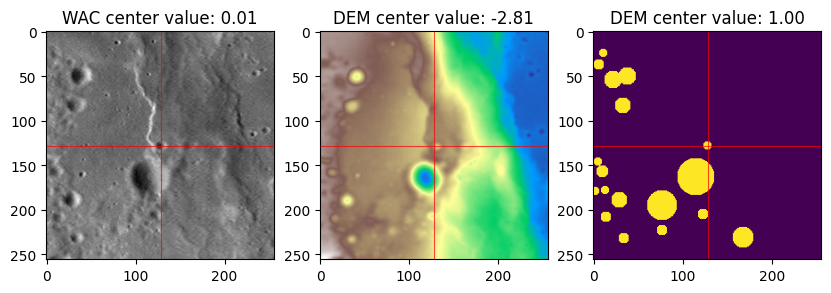

In [10]:
# checking the wac and dem aligh in terms of resolution and dimensions
patch_idx = 100

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(wac_check[patch_idx], cmap='gray')
axes[0].axhline(128, color='r', linewidth=0.8, alpha=0.7)
axes[0].axvline(128, color='r', linewidth=0.8, alpha=0.7)
axes[0].set_title(f"WAC center value: {wac_check[patch_idx][128, 128]:.2f}")

axes[1].imshow(dem_check[patch_idx], cmap='terrain')
axes[1].axhline(128, color='r', linewidth=0.8, alpha=0.7)
axes[1].axvline(128, color='r', linewidth=0.8, alpha=0.7)
axes[1].set_title(f"DEM center value: {dem_check[patch_idx][128, 128]:.2f}")

axes[2].imshow(mask_check[patch_idx])
axes[2].axhline(128, color='r', linewidth=0.8, alpha=0.7)
axes[2].axvline(128, color='r', linewidth=0.8, alpha=0.7)
axes[2].set_title(f"DEM center value: {mask_check[patch_idx][128, 128]:.2f}")


plt.show()

## Normalisation

- Normalise WAC and DEM patches to 0–1
- Check for NaNs patches
- Check class imbalance (crater pixels vs background)
- Train/val/test split

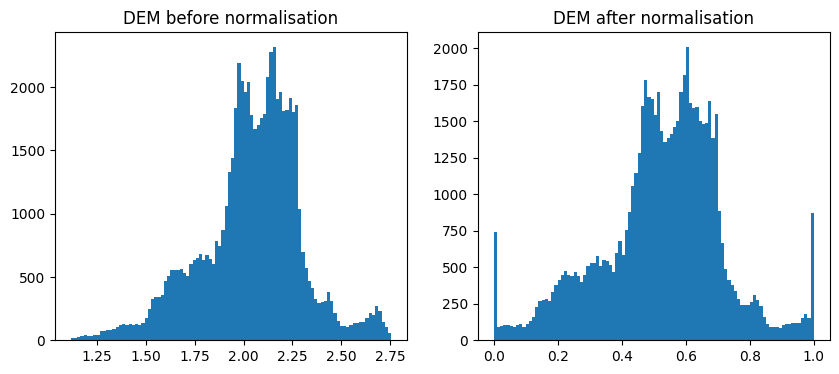

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(dem_patch.flatten(), bins=100)
axes[0].set_title('DEM before normalisation')

p1, p99 = np.percentile(dem_patch, [1, 99])
dem_norm = np.clip(dem_patch, p1, p99)
dem_norm = (dem_norm - p1) / (p99 - p1)

axes[1].hist(dem_norm.flatten(), bins=100)
axes[1].set_title('DEM after normalisation')

plt.show()

In [ ]:
# standard min-max normalisation (x - min) / (max - min)

# WAC: range(0–255) = (patch - 0) / ( 255 - 0)
# standard 8-bit (0–255)
norm_wac_batch = np.array(wac_batch) / 255.0

# DEM: elevation range varies per patch -> compute min/max from the data
# elevation has variable range and potential spikes -> percentile
norm_dem_batch = np.zeros((len(dem_batch), 256, 256), dtype=np.float32)
for j in range(len(dem_batch)):
    dem_patch = dem_batch[j]

    p1, p99 = np.percentile(dem_patch, [1, 99])
    norm_clip_dem_patch = np.clip(dem_patch, p1, p99)
    norm_dem_batch[j] = (norm_clip_dem_patch - p1) / (p99 - p1)

np.savez_compressed(f'patches/X_wac_norm_{batch_num}', norm_wac_batch)
np.savez_compressed(f'patches/X_dem_norm_{batch_num}', norm_dem_batch)

In [14]:
# NaN check — should both print False
print(np.isnan(norm_wac_batch).any())
print(np.isnan(norm_dem_batch).any())

False
False


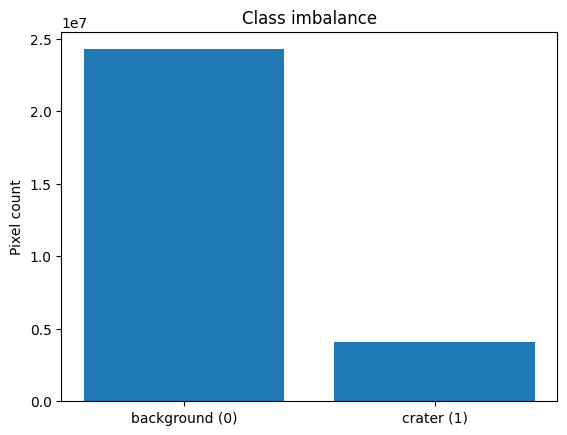

In [13]:
acc0 = 0
acc1 = 0

for mask in mask_batch:
    acc0 += (mask == 0).sum()
    acc1 += (mask == 1).sum()


plt.bar(['background (0)', 'crater (1)'], [acc0, acc1])

plt.title('Class imbalance')
plt.ylabel('Pixel count')

plt.show()

In [20]:
indices = np.arange(len(kept_labels))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

print(f'Train: {len(train_idx)} patches ({len(train_idx)/len(indices)*100:.1f}%)')
print(f'Val:   {len(val_idx)} patches ({len(val_idx)/len(indices)*100:.1f}%)')
print(f'Test:  {len(test_idx)} patches ({len(test_idx)/len(indices)*100:.1f}%)')

Train: 150803 patches (70.0%)
Val:   32315 patches (15.0%)
Test:  32315 patches (15.0%)


In [ ]:
np.save('patsplitsches/train_idx.npy', train_idx)
np.save('patches/val_idx.npy', val_idx)
np.save('patches/test_idx.npy', test_idx)